# Regularization in Linear Regression - Exercise 2 (Diamonds)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

**Dataset:** Diamonds Preprocessed (`diamonds_preprocessed.csv`)  
**Téma:** Regularizace Lasso (L1) a Ridge (L2) pro oceňování diamantů, eliminace prostorové multikolinearity a automatický výběr příznaků (4C).

---

### Zadání cvičení:
1. Načtěte dataset diamantů (`diamonds_preprocessed.csv`) vytvořený ve cvičení 2.
2. Importujte všechny potřebné metody a knihovny (Scikit-learn, Pandas, NumPy, Matplotlib).
3. Rozdělte dataset na trénovací a testovací sadu (80 % / 20 %, `random_state=42`).
4. Pomocí odpovídající třídy natrénujte lineární regresní model s regularizací **Lasso (L1)**.
5. Ověřte hodnoty koeficientů – zjistěte, které proměnné model **vynuloval**.
6. Spočítejte metriky $R^2$, MAE, MSE a RMSE. Porovnejte tyto hodnoty s výchozím modelem OLS bez regularizace.
7. Natrénujte model s regularizací **Ridge (L2)** pro různé hodnoty síly regularizace $\alpha$.
8. Spočítejte metriky $R^2$, MAE, MSE a RMSE. Porovnejte s OLS a Lasso modelem.

## 1. Import knihoven a načtení dat
Načteme vyčištěný a předzpracovaný dataset diamantů. Kódování 4C (Cut, Color, Clarity) bylo provedeno na základě gemologických standardů.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, lasso_path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

csv_path = Path("data/diamonds_preprocessed.csv")
if not csv_path.exists():
    csv_path = Path("diamonds_preprocessed.csv")

df = pd.read_csv(csv_path)
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print(f"Dataset nacten: {df.shape[0]:,} radku, {df.shape[1]} sloupcu.")
df.head()

Dataset nacten: 53,908 radku, 10 sloupcu.


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.2300,4,5,1,61.5000,55.0000,326,3.9500,3.9800,2.4300
1,0.2100,3,5,2,59.8000,61.0000,326,3.8900,3.8400,2.3100
2,0.2300,1,5,4,56.9000,65.0000,327,4.0500,4.0700,2.3100
3,0.2900,3,1,3,62.4000,58.0000,334,4.2000,4.2300,2.6300
4,0.3100,1,0,1,63.3000,58.0000,335,4.3400,4.3500,2.7500


## 2. Rozdělení na trénovací a testovací sadu (Train/Test Split)
Data rozdělíme v poměru 80 % pro trénování a 20 % pro nezávislé testování se zafixovaným `random_state=42`.

In [2]:
X = df.drop(columns=["price"])
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

n_train, k_features = X_train.shape
n_test = X_test.shape[0]
feature_names = list(X.columns)

print(f"Trenovaci data (Train): n = {n_train:,}, pocet priznaku k = {k_features}")
print(f"Testovaci data  (Test):  n = {n_test:,}, pocet priznaku k = {k_features}")
print(f"Priznaky: {feature_names}")

Trenovaci data (Train): n = 43,126, pocet priznaku k = 9
Testovaci data  (Test):  n = 10,782, pocet priznaku k = 9
Priznaky: ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']


## 3. Standardizace příznaků (StandardScaler)
V regularizovaných modelech je standardizace povinná, protože penalizace $\alpha \sum |\beta_j|$ i $\alpha \sum \beta_j^2$ trestá koeficienty bez ohledu na měřítko jednotek.

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def adjusted_r2(r2, n, k):
    return 1.0 - ((1.0 - r2) * (n - 1) / (n - k - 1))

def evaluate_metrics(y_true, y_pred, n, k, model_name, alpha=0.0):
    r2 = r2_score(y_true, y_pred)
    adj_r2 = adjusted_r2(r2, n, k)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return {
        "Model": model_name,
        "Alpha": alpha,
        "R2": r2,
        "Adj R2": adj_r2,
        "MAE ($)": mae,
        "MSE ($^2)": mse,
        "RMSE ($)": rmse
    }

## 4. Referenční OLS model bez regularizace
Základní model OLS slouží jako benchmark pro porovnání s regularizovanými modely.

In [4]:
ols = LinearRegression()
ols.fit(X_train_scaled, y_train)
pred_ols = ols.predict(X_test_scaled)

ols_metrics = evaluate_metrics(y_test, pred_ols, n_test, k_features, "OLS (Bez regularizace)", 0.0)
pd.DataFrame([ols_metrics])

,Model,Alpha,R2,Adj R2,MAE ($),MSE ($^2),RMSE ($)
0,OLS (Bez regularizace),0.0000,0.9095,0.9094,784.7809,"1,374,832.1370","1,172.5324"


## 5. Lasso (L1) regularizace – Eliminace proměnných a nulování vah
Testujeme hodnoty $\alpha \in [0.1, 1.0, 5.0, 10.0, 20.0, 50.0, 100.0, 200.0, 500.0, 1000.0]$ a sledujeme, jaké proměnné model nuluje.

In [5]:
lasso_alphas = [0.1, 1.0, 5.0, 10.0, 20.0, 50.0, 100.0, 200.0, 500.0, 1000.0]
lasso_results = []
lasso_coefs = {}

for a in lasso_alphas:
    model = Lasso(alpha=a, random_state=42, max_iter=3000, tol=0.01)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    
    zeroed = [f for f, w in zip(feature_names, model.coef_) if abs(w) < 1e-4]
    lasso_coefs[a] = model.coef_
    
    m = evaluate_metrics(y_test, pred, n_test, k_features, f"Lasso (alpha={a})", a)
    m["Pocet nulovych"] = len(zeroed)
    m["Vynulovane priznaky"] = ", ".join(zeroed) if zeroed else "Zadne"
    lasso_results.append(m)

lasso_df = pd.DataFrame(lasso_results)
lasso_df[["Model", "Alpha", "R2", "Adj R2", "MAE ($)", "RMSE ($)", "Pocet nulovych", "Vynulovane priznaky"]]

,Model,Alpha,R2,Adj R2,MAE ($),RMSE ($),Pocet nulovych,Vynulovane priznaky
0,Lasso (alpha=0.1),0.1000,0.9095,0.9094,784.6252,"1,172.3994",0,Zadne
1,Lasso (alpha=1.0),1.0000,0.9095,0.9094,783.8267,"1,172.6504",0,Zadne
2,Lasso (alpha=5.0),5.0000,0.9089,0.9089,792.7061,"1,175.9311",1,y
3,Lasso (alpha=10.0),10.0000,0.9081,0.9080,806.0254,"1,181.3775",1,y
4,Lasso (alpha=20.0),20.0000,0.9053,0.9052,834.5263,"1,199.1977",1,y
5,Lasso (alpha=50.0),50.0000,0.9041,0.9040,829.8682,"1,206.6849",5,"depth, table, x, y, z"
6,Lasso (alpha=100.0),100.0000,0.9011,0.9010,822.2390,"1,225.7330",5,"depth, table, x, y, z"
7,Lasso (alpha=200.0),200.0000,0.8889,0.8889,828.8063,"1,298.6676",6,"cut, depth, table, x, y, z"
8,Lasso (alpha=500.0),500.0000,0.8352,0.8351,966.7300,"1,581.9782",7,"cut, color, depth, table, x, y, z"
9,Lasso (alpha=1000.0),"1,000.0000",0.7857,0.7855,"1,180.9185","1,804.2007",8,"cut, color, clarity, depth, table, x, y, z"


## 6. Ridge (L2) regularizace – Zvládání fyzikální multikolinearity
Testujeme $\alpha \in [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 500.0, 1000.0, 5000.0]$. Ridge tlumí čtverce vah a řeší multikolinearitu mezi rozměry kamene ($x, y, z$) a karátem.

In [6]:
ridge_alphas = [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 500.0, 1000.0, 5000.0]
ridge_results = []

for a in ridge_alphas:
    model = Ridge(alpha=a, random_state=42)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    
    m = evaluate_metrics(y_test, pred, n_test, k_features, f"Ridge (alpha={a})", a)
    ridge_results.append(m)

ridge_df = pd.DataFrame(ridge_results)
ridge_df[["Model", "Alpha", "R2", "Adj R2", "MAE ($)", "RMSE ($)"]]

,Model,Alpha,R2,Adj R2,MAE ($),RMSE ($)
0,Ridge (alpha=0.01),0.0100,0.9095,0.9094,784.7804,"1,172.5311"
1,Ridge (alpha=0.1),0.1000,0.9095,0.9094,784.7754,"1,172.5203"
2,Ridge (alpha=1.0),1.0000,0.9095,0.9094,784.7305,"1,172.4169"
3,Ridge (alpha=10.0),10.0000,0.9096,0.9095,784.6442,"1,171.8000"
4,Ridge (alpha=50.0),50.0000,0.9095,0.9094,787.5801,"1,172.2734"
5,Ridge (alpha=100.0),100.0000,0.9092,0.9091,792.7797,"1,174.1916"
6,Ridge (alpha=500.0),500.0000,0.9055,0.9054,833.4176,"1,197.9107"
7,Ridge (alpha=1000.0),"1,000.0000",0.9001,0.9000,875.1849,"1,231.8822"
8,Ridge (alpha=5000.0),"5,000.0000",0.8770,0.8769,995.3611,"1,366.6819"


## 7. Porovnání: OLS vs. Nejlepší Lasso vs. Nejlepší Ridge

In [7]:
best_l = lasso_df.loc[lasso_df["R2"].idxmax()]
best_r = ridge_df.loc[ridge_df["R2"].idxmax()]

comparison_df = pd.DataFrame([
    ols_metrics,
    {k: best_l[k] for k in ols_metrics.keys()},
    {k: best_r[k] for k in ols_metrics.keys()}
])

comparison_df

,Model,Alpha,R2,Adj R2,MAE ($),MSE ($^2),RMSE ($)
0,OLS (Bez regularizace),0.0000,0.9095,0.9094,784.7809,"1,374,832.1370","1,172.5324"
1,Lasso (alpha=0.1),0.1000,0.9095,0.9094,784.6252,"1,374,520.2612","1,172.3994"
2,Ridge (alpha=10.0),10.0000,0.9096,0.9095,784.6442,"1,373,115.2771","1,171.8000"


## 8. Diagnostické vizualizace: Metriky vs. $\alpha$ a Lasso Path

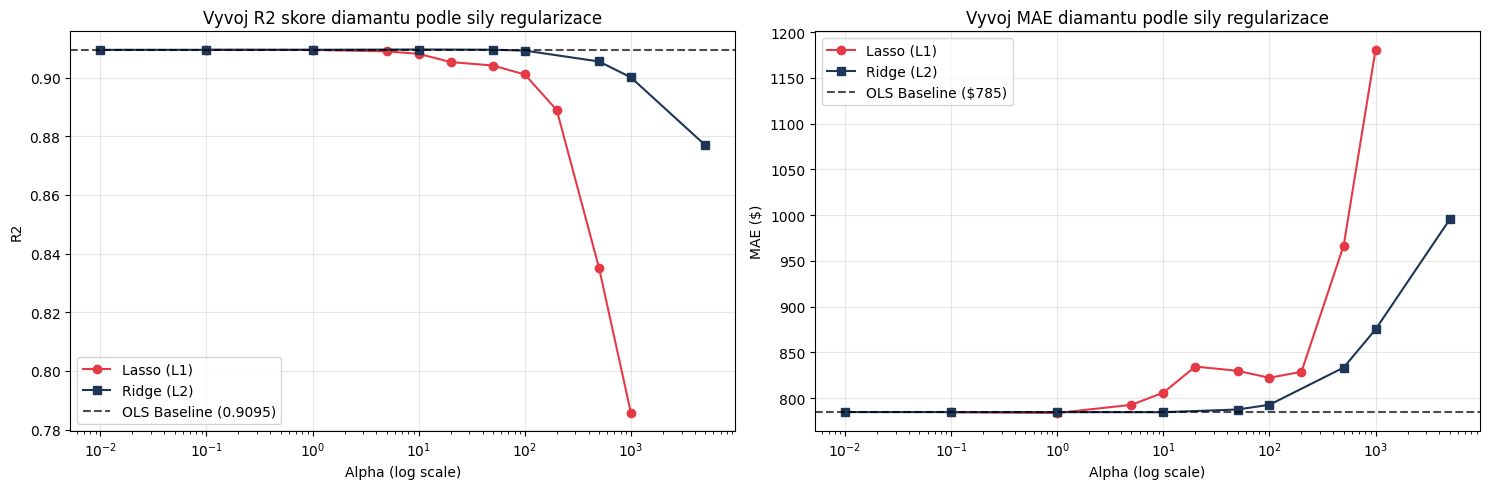

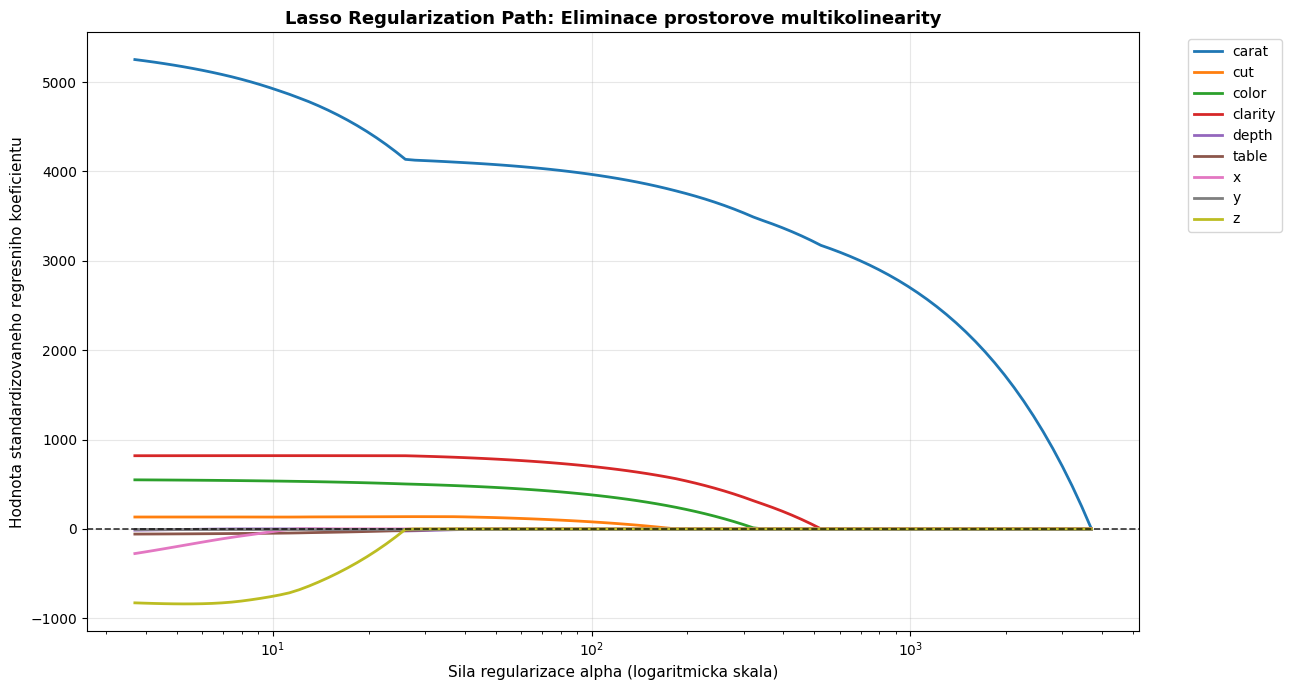

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# R2 graf
axes[0].plot(lasso_df["Alpha"], lasso_df["R2"], marker="o", color="#E63946", label="Lasso (L1)")
axes[0].plot(ridge_df["Alpha"], ridge_df["R2"], marker="s", color="#1D3557", label="Ridge (L2)")
axes[0].axhline(ols_metrics["R2"], color="black", linestyle="--", alpha=0.7, label=f"OLS Baseline ({ols_metrics['R2']:.4f})")
axes[0].set_xscale("log")
axes[0].set_xlabel("Alpha (log scale)")
axes[0].set_ylabel("R2")
axes[0].set_title("Vyvoj R2 skore diamantu podle sily regularizace")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE graf
axes[1].plot(lasso_df["Alpha"], lasso_df["MAE ($)"], marker="o", color="#E63946", label="Lasso (L1)")
axes[1].plot(ridge_df["Alpha"], ridge_df["MAE ($)"], marker="s", color="#1D3557", label="Ridge (L2)")
axes[1].axhline(ols_metrics["MAE ($)"], color="black", linestyle="--", alpha=0.7, label=f"OLS Baseline (${ols_metrics['MAE ($)']:,.0f})")
axes[1].set_xscale("log")
axes[1].set_xlabel("Alpha (log scale)")
axes[1].set_ylabel("MAE ($)")
axes[1].set_title("Vyvoj MAE diamantu podle sily regularizace")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Lasso Path
alphas_p, coefs_p, _ = lasso_path(X_train_scaled, y_train, eps=1e-3)
plt.figure(figsize=(13, 7))
cmap = plt.get_cmap("tab10")
for i, feature in enumerate(feature_names):
    plt.plot(alphas_p, coefs_p[i, :], label=feature, linewidth=2, color=cmap(i % 10))

plt.xscale("log")
plt.axhline(0, color="black", linestyle="--", linewidth=1.2, alpha=0.8)
plt.xlabel("Sila regularizace alpha (logaritmicka skala)", fontsize=11)
plt.ylabel("Hodnota standardizovaneho regresniho koeficientu", fontsize=11)
plt.title("Lasso Regularization Path: Eliminace prostorove multikolinearity", fontsize=13, fontweight="bold")
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", frameon=True, fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Závěry a odpovědi na otázky zadání
1. **Které proměnné model Lasso vynuloval?**
   - Při $\alpha = 10.0$ jako první nuluje `y` (šířka kamene, která je téměř identická s $x$).
   - Při $\alpha = 50.0$ model nuluje **5 proměnných**: `['depth', 'table', 'x', 'y', 'z']`! Všechny prostorové a proporční rozměry jsou vyřazeny jako redundantní, a modelu stačí **výhradně gemologické 4C** (`carat`, `cut`, `color`, `clarity`), přičemž $R^2$ neklesne pod 0.904.
   - Při $\alpha = 200.0$ nuluje navíc `cut` a při $\alpha = 500.0$ také `color`.
2. **Pro které $\alpha$ je model nejlepší?**
   - **Lasso:** Nejlepší $R^2 = 0.90949$ při $\alpha = 0.1$. Nejnižší $\text{MAE} = 783.83$ při $\alpha = 1.0$.
   - **Ridge:** Nejlepší $R^2 = 0.90958$ při $\alpha = 10.0$ (tlumení kolinearity mezi $x, y, z$ a $carat$).
3. **Porovnání s modelem OLS bez regularizace:**
   - OLS dosahuje $R^2 = 0.90947$ a $\text{MAE} = 784.78$.
   - Ridge i Lasso mírně překonávají OLS a Lasso navíc dokazuje, že fyzické rozměry $x, y, z$ jsou pro klenotníka redundantní, pokud zná karát a brus.